# Model Training

Train an XGBoost classifier to predict per-side blunders using features extracted at move 15.

Input: features.parquet (29,082 rows, one per player per game)
Output: trained model artifact logged to MLflow


In [1]:
import sys
import numpy as np
import pandas as pd
import xgboost as xgb
import shap
import mlflow
import mlflow.xgboost
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, ConfusionMatrixDisplay
)

sys.path.append(str(Path().resolve().parent))
from config import (
    FEATURES_PATH, MODELS_DIR, MLFLOW_TRACKING_URI, MLFLOW_EXPERIMENT, MLFLOW_MODEL_NAME,
    XGBOOST_PARAMS,FEATURE_COLS, N_CV_FOLDS, TEST_SIZE, RANDOM_STATE
)


d:\DS_ML_journey\chess_blunder\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_parquet(FEATURES_PATH)
print(df.shape)
df.head(3)

(29082, 13)


,game_id,side,player_elo,elo_diff,time_control,eval_at_snapshot,eval_volatility,eval_trend,material_balance,material_imbalance,king_attackers,has_castled,blunder_label
0,https://lichess.org/oXyWZjvn,white,1802,11,600,63.0,43.744821,16.4,0,0,0,0,1
1,https://lichess.org/oXyWZjvn,black,1791,-11,600,74.0,42.857619,20.6,0,0,0,0,0
2,https://lichess.org/clKpvLl6,white,1270,-67,600,306.0,106.602064,56.2,-1,1,0,0,0


## Train/Test Split

Split by game_id to prevent data leakage — white and black rows from the same game
must not appear in both train and test sets.


In [3]:
game_ids = df["game_id"].unique()
train_ids, test_ids = train_test_split(game_ids, test_size=TEST_SIZE, random_state=RANDOM_STATE)

train_df = df[df["game_id"].isin(train_ids)].reset_index(drop=True)
test_df = df[df["game_id"].isin(test_ids)].reset_index(drop=True)

print(f"Train: {train_df.shape}, Test: {test_df.shape}")
print(f"Train blunder rate: {train_df['blunder_label'].mean():.4f}")
print(f"Test blunder rate: {test_df['blunder_label'].mean():.4f}")

Train: (23264, 13), Test: (5818, 13)
Train blunder rate: 0.1466
Test blunder rate: 0.1392


## Features

Drop non-feature columns before training. `game_id` and `side` are identifiers,
`blunder_label` is the target.


In [4]:
X_train = train_df[FEATURE_COLS]
y_train = train_df["blunder_label"]
X_test  = test_df[FEATURE_COLS]
y_test  = test_df["blunder_label"]

print("Features:", FEATURE_COLS)
print("Class balance (train):", y_train.value_counts().to_dict())


Features: ['player_elo', 'elo_diff', 'time_control', 'eval_at_snapshot', 'eval_volatility', 'eval_trend', 'material_balance', 'material_imbalance', 'king_attackers', 'has_castled']
Class balance (train): {0: 19854, 1: 3410}


## Cross-Validation

5-fold CV on training set split by game_id — prevents white and black rows from the
same game appearing in different folds, which would leak positional information.


In [5]:
game_ids_train = train_df["game_id"].unique()
game_labels = np.array([
    train_df[train_df["game_id"] == gid]["blunder_label"].max()
    for gid in game_ids_train
])

kf = StratifiedKFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_aucs, cv_precs = [], []

for fold_train_idx, fold_val_idx in kf.split(game_ids_train, game_labels):
    fold_train_ids = game_ids_train[fold_train_idx]
    fold_val_ids   = game_ids_train[fold_val_idx]

    X_fold_train = train_df[train_df["game_id"].isin(fold_train_ids)][FEATURE_COLS]
    y_fold_train = train_df[train_df["game_id"].isin(fold_train_ids)]["blunder_label"]
    X_fold_val   = train_df[train_df["game_id"].isin(fold_val_ids)][FEATURE_COLS]
    y_fold_val   = train_df[train_df["game_id"].isin(fold_val_ids)]["blunder_label"]

    m = xgb.XGBClassifier(**XGBOOST_PARAMS, verbosity=0)
    m.fit(X_fold_train, y_fold_train)
    proba = m.predict_proba(X_fold_val)[:, 1]

    cv_aucs.append(roc_auc_score(y_fold_val, proba))
    cv_precs.append(average_precision_score(y_fold_val, proba))

cv_results = {
    "test_roc_auc": np.array(cv_aucs),
    "test_average_precision": np.array(cv_precs),
}

print(f"CV ROC-AUC:  {np.mean(cv_aucs):.4f} ± {np.std(cv_aucs):.4f}")
print(f"CV Avg Prec: {np.mean(cv_precs):.4f} ± {np.std(cv_precs):.4f}")


CV ROC-AUC:  0.6844 ± 0.0063
CV Avg Prec: 0.2585 ± 0.0044


## Final Model Training & MLflow Logging


In [6]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT)


with mlflow.start_run() as run:
    model = xgb.XGBClassifier(**XGBOOST_PARAMS, verbosity=0)
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    roc_auc  = roc_auc_score(y_test, y_pred_proba)
    avg_prec = average_precision_score(y_test, y_pred_proba)

    mlflow.log_params(XGBOOST_PARAMS)
    mlflow.log_param("n_features", len(FEATURE_COLS))
    mlflow.log_param("train_size", len(X_train))
    mlflow.log_param("test_size", len(X_test))
    mlflow.log_metric("roc_auc", roc_auc)
    mlflow.log_metric("avg_precision", avg_prec)
    mlflow.log_metric("cv_roc_auc_mean", cv_results["test_roc_auc"].mean())
    mlflow.log_metric("cv_roc_auc_std", cv_results["test_roc_auc"].std())
    mlflow.log_metric("cv_avg_prec_mean", cv_results["test_average_precision"].mean())
    mlflow.log_metric("cv_avg_prec_std", cv_results["test_average_precision"].std())
    mlflow.xgboost.log_model(model, artifact_path="model", registered_model_name=MLFLOW_MODEL_NAME)

    print(f"ROC-AUC:       {roc_auc:.4f}")
    print(f"Avg Precision: {avg_prec:.4f}")
    print(f"Run ID: {run.info.run_id}")



d:\DS_ML_journey\chess_blunder\.venv\Lib\site-packages\xgboost\sklearn.py:1116: UserWarning: [22:41:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\c_api\c_api.cc:1573: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  self.get_booster().save_model(fname)
2026/05/19 22:41:17 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


ROC-AUC:       0.6787
Avg Precision: 0.2413
Run ID: 56613ad60cd84304959510558c383e1c


Successfully registered model 'blunder_predictor'.
Created version '1' of model 'blunder_predictor'.


## Evaluation


              precision    recall  f1-score   support

  no blunder       0.90      0.73      0.81      5008
     blunder       0.24      0.52      0.32       810

    accuracy                           0.70      5818
   macro avg       0.57      0.62      0.57      5818
weighted avg       0.81      0.70      0.74      5818



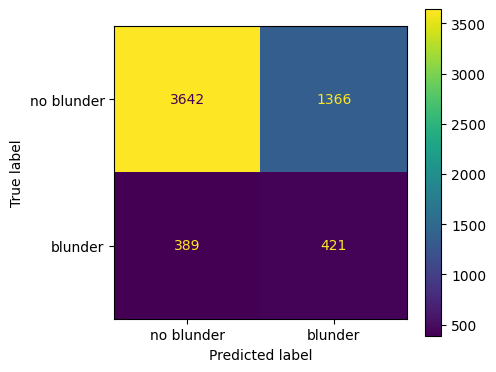

In [7]:
print(classification_report(y_test, y_pred, target_names=["no blunder", "blunder"]))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["no blunder", "blunder"], ax=ax)
plt.tight_layout()
plt.show()


## SHAP Feature Importance

SHAP values explain how much each feature contributes to each prediction.
A high positive SHAP value pushes the prediction toward blunder=1.


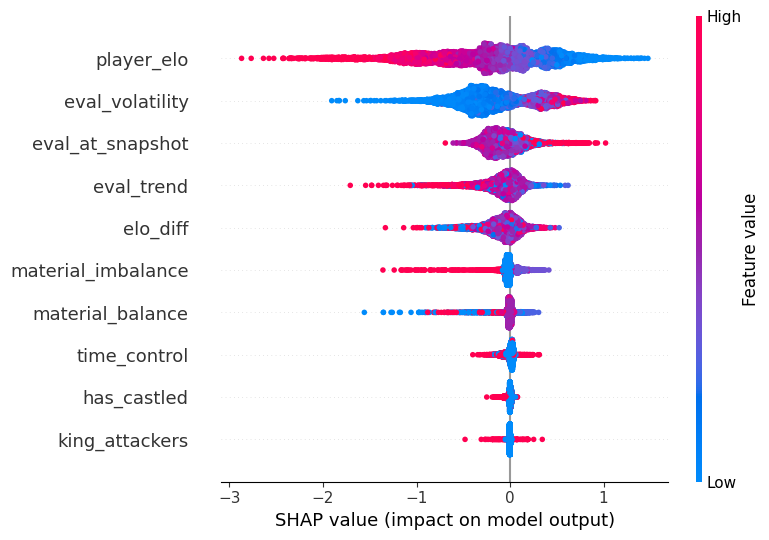

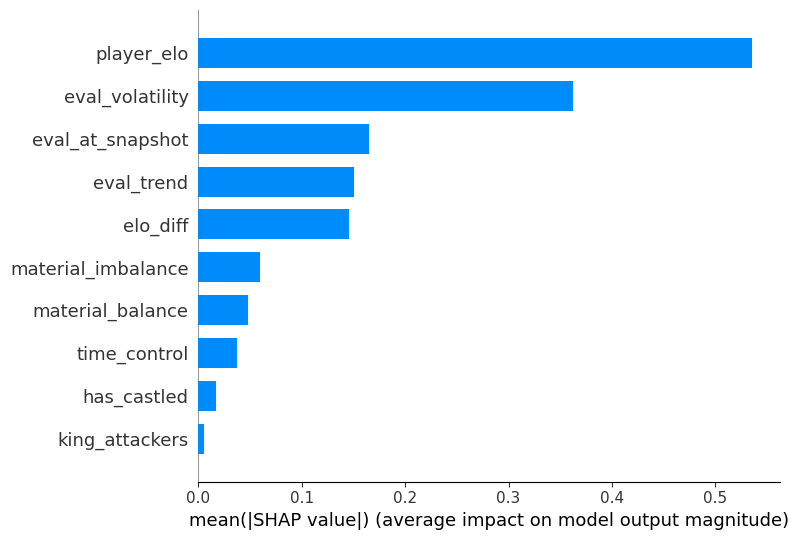

In [8]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=FEATURE_COLS)
shap.summary_plot(shap_values, X_test, feature_names=FEATURE_COLS, plot_type="bar")

